In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
import matplotlib.patheffects as pe

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import compute_AR_from_Q, collect_tracking_R_with_Omega0, tracking_kdtree_with_Omega0, day_plot


In [3]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'

dataset = nc.Dataset(fname)

lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))

def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2

dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])

x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [4]:
df_doppio = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_DOPPIO_SEACOFS_26yr.pkl')
df_doppio['w'] *= 1e-3; df_doppio['Omega0'] *= 1e-3; df_doppio['Omega'] *= 1e-3; #df_doppio['psi0'] *= 1e9
df_doppio


,Day,fnumber,nxc,nyc,nCyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R
0,1462,1461,830.0,1515.0,AE,829.879126,1515.297884,0.000016,"[[0.7054724746035225, -0.17299518294950286], [...",0.000007,0.000008,96.456316,-38.462785,63.384028
1,1462,1461,358.0,1408.0,AE,357.902634,1407.794571,0.000032,"[[1.2525415454561337, -0.37318304544145586], [...",0.000015,0.000014,78.042405,-41.260426,50.068171
2,1462,1461,928.0,1356.0,CE,928.181752,1356.070550,-0.000011,"[[0.9184334895938384, -0.6568144522261018], [-...",-0.000004,-0.000007,118.032741,47.992205,74.597458
3,1462,1461,506.0,1354.0,CE,505.750855,1353.499933,-0.000032,"[[1.0915204469734063, -0.17483272531676586], [...",-0.000016,-0.000013,106.666574,75.106895,69.457705
4,1462,1461,754.0,1285.0,AE,753.849693,1284.689807,0.000022,"[[1.300245004042572, -0.37537759847059776], [-...",0.000010,0.000008,103.327517,-44.066805,65.961546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416246,10650,10641,349.0,158.0,AE,348.663439,158.138527,0.000033,"[[1.3863808771116255, 0.04649055064735413], [0...",0.000016,0.000012,110.552001,-72.997132,43.099927
416247,10650,10641,973.0,126.0,CE,978.294053,127.970950,-0.000004,"[[0.6233322936879349, -0.5502050858849237], [-...",-0.000001,-0.000002,75.127332,4.241051,34.482872
416248,10650,10641,805.0,95.0,AE,804.765913,95.382012,0.000011,"[[1.2619918374118362, 0.3980497594289241], [0....",0.000005,0.000006,60.426625,-10.779905,45.893895
416249,10650,10641,157.0,34.0,CE,157.210669,33.449590,-0.000007,"[[0.9874338034387458, 0.628992620695803], [0.6...",-0.000003,-0.000004,141.142981,36.082072,34.764443


In [5]:
def clean_doppio(df_doppio, X_grid, Y_grid, threshold=4, Omega0_thresh=5e-5):

    required = ['nCyc', 'xc', 'yc', 'nxc', 'nyc', 'Omega0']

    df = df_doppio.dropna(subset=required).copy()
    print(f'1. Removed {len(df_doppio) - len(df)} eddy-days with NaNs')

    # --- cyclonicity consistency ---
    nenc_cyc = np.where(df['nCyc'].eq('AE'), 1, -1)
    doppio_cyc = np.sign(df['Omega0'].values)

    cyc_mask = nenc_cyc == doppio_cyc
    df = df.loc[cyc_mask].copy()

    print(f'2. Removed {cyc_mask.size - cyc_mask.sum()} eddy-days with cyclonicity mismatch')

    # --- center error ---
    err = np.hypot(
        df['xc'] - df['nxc'],
        df['yc'] - df['nyc']
    )

    df['err'] = err

    # --- domain bounds ---
    boundary_mask = (
        df['xc'].between(0, X_grid.max(), inclusive='neither')
        & df['yc'].between(0, Y_grid.max(), inclusive='neither')
    )

    # --- robust center-error filtering ---
    log_err = np.log1p(err)

    err_med = np.median(log_err)
    err_mad = np.median(np.abs(log_err - err_med))

    if err_mad == 0:
        upper_err = np.inf
    else:
        upper_err = np.expm1(
            err_med + threshold * err_mad / 0.6745
        )

    center_mask = err <= upper_err

    # optional hard cap
    # center_mask &= (err <= 50)

    # --- Omega0 filter ---
    df['Omega0_abs'] = df['Omega0'].abs()

    omega_mask = df['Omega0_abs'] <= Omega0_thresh

    # --- sanity checks ---
    sanity_mask = (
        np.isfinite(err)
        & np.isfinite(df['Omega0_abs'])
        & (df['Omega0_abs'] > 0)
    )

    # --- combined mask ---
    final_mask = (
        boundary_mask
        & center_mask
        & omega_mask
        & sanity_mask
    )

    # --- diagnostics ---
    print('\nThresholds:')
    print(f'Omega0_abs: 0 → {Omega0_thresh} 1/s')
    print(f'Center error: 0 → {upper_err:.3f} km')

    df_clean = (
        df.loc[final_mask]
        .copy()
        .reset_index(drop=True)
    )

    print(f'\n3. Removed {len(df) - len(df_clean)} eddy-days by QC masks')
    print(f'Final retained: {len(df_clean)} eddy-days')

    return df_clean


In [6]:
df_clean = clean_doppio(df_doppio, X_grid, Y_grid)


1. Removed 38768 eddy-days with NaNs
2. Removed 682 eddy-days with cyclonicity mismatch

Thresholds:
Omega0_abs: 0 → 5e-05 1/s
Center error: 0 → 23.367 km

3. Removed 9607 eddy-days by QC masks
Final retained: 367194 eddy-days


,Day,fnumber,nxc,nyc,nCyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R,err,Omega0_abs
0,1462,1461,830.0,1515.0,AE,829.879126,1515.297884,0.000016,"[[0.7054724746035225, -0.17299518294950286], [...",0.000007,0.000008,96.456316,-38.462785,63.384028,0.321474,0.000007
1,1462,1461,358.0,1408.0,AE,357.902634,1407.794571,0.000032,"[[1.2525415454561337, -0.37318304544145586], [...",0.000015,0.000014,78.042405,-41.260426,50.068171,0.227335,0.000015
2,1462,1461,928.0,1356.0,CE,928.181752,1356.070550,-0.000011,"[[0.9184334895938384, -0.6568144522261018], [-...",-0.000004,-0.000007,118.032741,47.992205,74.597458,0.194964,0.000004
3,1462,1461,506.0,1354.0,CE,505.750855,1353.499933,-0.000032,"[[1.0915204469734063, -0.17483272531676586], [...",-0.000016,-0.000013,106.666574,75.106895,69.457705,0.558695,0.000016
4,1462,1461,754.0,1285.0,AE,753.849693,1284.689807,0.000022,"[[1.300245004042572, -0.37537759847059776], [-...",0.000010,0.000008,103.327517,-44.066805,65.961546,0.344691,0.000010


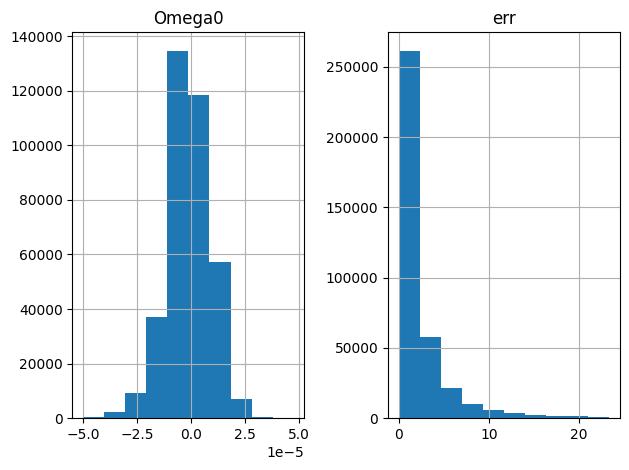

In [7]:
df = df_clean.copy()
df.hist(['Omega0', 'err'])
plt.tight_layout()
df.head()


In [7]:
# df = df_doppio.copy()
# df['err'] = np.hypot(
#     df['xc'] - df['nxc'],
#     df['yc'] - df['nyc']
# )
# df.hist(['Omega0', 'err'])
# plt.tight_layout()
# df.head()


Tracking

In [8]:
df_data = df_clean.copy()
df_data = df_data.rename(columns={'nCyc': 'Cyc'})
df_data['eddy_idx'] = df_data.groupby('Day').cumcount()
df_data


,Day,fnumber,nxc,nyc,Cyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R,err,Omega0_abs,eddy_idx
0,1462,1461,830.0,1515.0,AE,829.879126,1515.297884,0.000016,"[[0.7054724746035225, -0.17299518294950286], [...",0.000007,0.000008,96.456316,-38.462785,63.384028,0.321474,0.000007,0
1,1462,1461,358.0,1408.0,AE,357.902634,1407.794571,0.000032,"[[1.2525415454561337, -0.37318304544145586], [...",0.000015,0.000014,78.042405,-41.260426,50.068171,0.227335,0.000015,1
2,1462,1461,928.0,1356.0,CE,928.181752,1356.070550,-0.000011,"[[0.9184334895938384, -0.6568144522261018], [-...",-0.000004,-0.000007,118.032741,47.992205,74.597458,0.194964,0.000004,2
3,1462,1461,506.0,1354.0,CE,505.750855,1353.499933,-0.000032,"[[1.0915204469734063, -0.17483272531676586], [...",-0.000016,-0.000013,106.666574,75.106895,69.457705,0.558695,0.000016,3
4,1462,1461,754.0,1285.0,AE,753.849693,1284.689807,0.000022,"[[1.300245004042572, -0.37537759847059776], [-...",0.000010,0.000008,103.327517,-44.066805,65.961546,0.344691,0.000010,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367189,10650,10641,349.0,158.0,AE,348.663439,158.138527,0.000033,"[[1.3863808771116255, 0.04649055064735413], [0...",0.000016,0.000012,110.552001,-72.997132,43.099927,0.363955,0.000016,22
367190,10650,10641,973.0,126.0,CE,978.294053,127.970950,-0.000004,"[[0.6233322936879349, -0.5502050858849237], [-...",-0.000001,-0.000002,75.127332,4.241051,34.482872,5.649039,0.000001,23
367191,10650,10641,805.0,95.0,AE,804.765913,95.382012,0.000011,"[[1.2619918374118362, 0.3980497594289241], [0....",0.000005,0.000006,60.426625,-10.779905,45.893895,0.448028,0.000005,24
367192,10650,10641,157.0,34.0,CE,157.210669,33.449590,-0.000007,"[[0.9874338034387458, 0.628992620695803], [0.6...",-0.000003,-0.000004,141.142981,36.082072,34.764443,0.589349,0.000003,25


Optimal R = 1

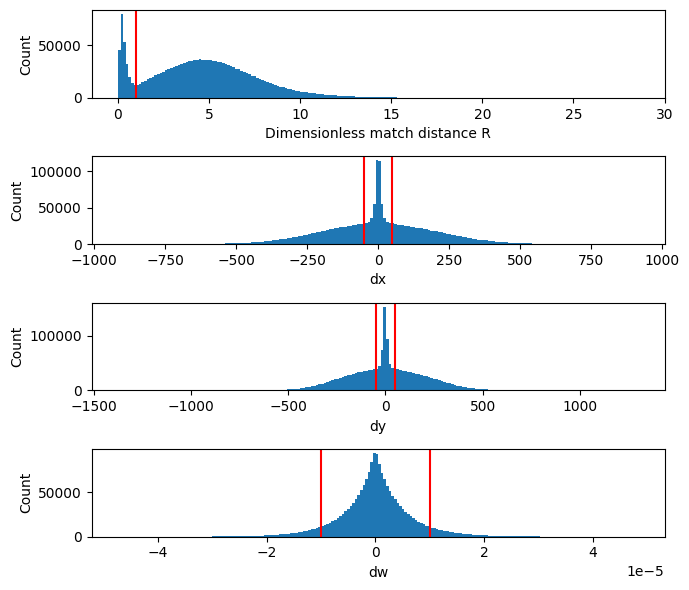

In [10]:
# df = df_data.copy()
# df_R = collect_tracking_R_with_Omega0(
#     df,
#     L_SCALE=50,
#     Omega0_SCALE=1e-5,
#     LOOKBACK=4
# )

# fig, axes = plt.subplots(4, 1, figsize=(7, 6), sharex=False)

# # R
# axes[0].hist(df_R['R'], bins=200)
# axes[0].axvline(1, color='r')
# axes[0].set_xlabel('Dimensionless match distance R')
# axes[0].set_ylabel('Count')

# # dx
# axes[1].hist(df_R['dx'], bins=200)
# axes[1].axvline(-50, color='r')
# axes[1].axvline(50, color='r')
# axes[1].set_xlabel('dx')
# axes[1].set_ylabel('Count')

# # dy
# axes[2].hist(df_R['dy'], bins=200)
# axes[2].axvline(-50, color='r')
# axes[2].axvline(50, color='r')
# axes[2].set_xlabel('dy')
# axes[2].set_ylabel('Count')

# # dw
# axes[3].hist(df_R['dO'], bins=200)
# axes[3].axvline(-1e-5, color='r')
# axes[3].axvline(1e-5, color='r')
# axes[3].set_xlabel('dw')
# axes[3].set_ylabel('Count')

# plt.tight_layout()
# plt.show()


Text(0, 0.5, 'Frequency')

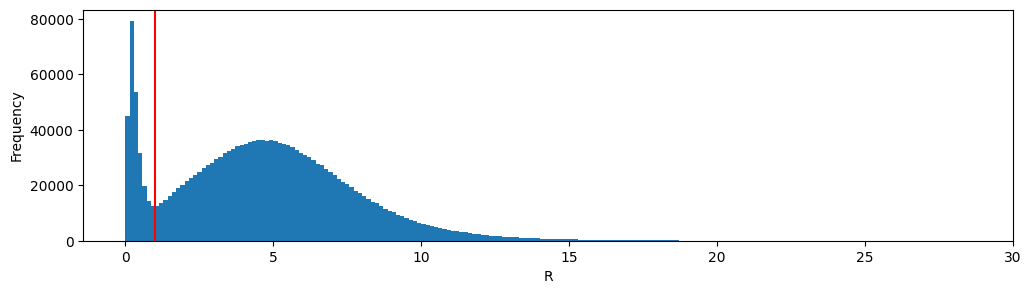

In [11]:
# # R
# fig, ax = plt.subplots(figsize=(12,3))
# ax.hist(df_R['R'], bins=200)
# ax.axvline(1, color='r')
# ax.set_xlabel('R')
# ax.set_ylabel('Frequency')




Tracking

In [ ]:
break

In [9]:
df = df_data.copy()#[df_data.Day <= df_data.Day.min() + 200]

start_ID = np.arange(len(df[df.Day==df.Day.min()]))
next_num = np.max(start_ID) + 1

df_tracked = tracking_kdtree_with_Omega0(
    df,
    start_ID=start_ID,
    next_num=next_num,
    L_SCALE=50,
    Omega0_SCALE=1e-5,
    R_THRESH=1, 
    LOOKBACK=4
)


Day 1600, elapsed: 31.00s
Day 1800, elapsed: 96.46s
Day 2000, elapsed: 145.37s
Day 2200, elapsed: 202.74s
Day 2400, elapsed: 249.58s
Day 2600, elapsed: 311.66s
Day 2800, elapsed: 363.36s
Day 3000, elapsed: 413.85s
Day 3200, elapsed: 465.78s
Day 3400, elapsed: 509.24s
Day 3600, elapsed: 563.01s
Day 3800, elapsed: 608.34s
Day 4000, elapsed: 666.36s
Day 4200, elapsed: 715.08s
Day 4400, elapsed: 773.28s
Day 4600, elapsed: 823.43s
Day 4800, elapsed: 878.19s
Day 5000, elapsed: 934.65s
Day 5200, elapsed: 988.84s
Day 5400, elapsed: 1046.25s
Day 5600, elapsed: 1095.99s
Day 5800, elapsed: 1154.36s
Day 6000, elapsed: 1201.43s
Day 6200, elapsed: 1268.62s
Day 6400, elapsed: 1319.88s
Day 6600, elapsed: 1380.18s
Day 6800, elapsed: 1440.64s
Day 7000, elapsed: 1500.94s
Day 7200, elapsed: 1556.06s
Day 7400, elapsed: 1603.27s
Day 7600, elapsed: 1655.47s
Day 7800, elapsed: 1701.72s
Day 8000, elapsed: 1765.85s
Day 8200, elapsed: 1814.56s
Day 8400, elapsed: 1879.43s
Day 8600, elapsed: 1924.39s
Day 8800, ela

In [10]:
df_tracked


,Day,fnumber,nxc,nyc,Cyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R,err,Omega0_abs,eddy_idx,Eddy,next_num
0,1462,1461,830.0,1515.0,AE,829.879126,1515.297884,0.000016,"[[0.7054724746035225, -0.17299518294950286], [...",0.000007,0.000008,96.456316,-38.462785,63.384028,0.321474,0.000007,0,0,74927
1,1462,1461,358.0,1408.0,AE,357.902634,1407.794571,0.000032,"[[1.2525415454561337, -0.37318304544145586], [...",0.000015,0.000014,78.042405,-41.260426,50.068171,0.227335,0.000015,1,1,74927
2,1462,1461,928.0,1356.0,CE,928.181752,1356.070550,-0.000011,"[[0.9184334895938384, -0.6568144522261018], [-...",-0.000004,-0.000007,118.032741,47.992205,74.597458,0.194964,0.000004,2,2,74927
3,1462,1461,506.0,1354.0,CE,505.750855,1353.499933,-0.000032,"[[1.0915204469734063, -0.17483272531676586], [...",-0.000016,-0.000013,106.666574,75.106895,69.457705,0.558695,0.000016,3,3,74927
4,1462,1461,754.0,1285.0,AE,753.849693,1284.689807,0.000022,"[[1.300245004042572, -0.37537759847059776], [-...",0.000010,0.000008,103.327517,-44.066805,65.961546,0.344691,0.000010,4,4,74927
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367189,10650,10641,349.0,158.0,AE,348.663439,158.138527,0.000033,"[[1.3863808771116255, 0.04649055064735413], [0...",0.000016,0.000012,110.552001,-72.997132,43.099927,0.363955,0.000016,22,74889,74927
367190,10650,10641,973.0,126.0,CE,978.294053,127.970950,-0.000004,"[[0.6233322936879349, -0.5502050858849237], [-...",-0.000001,-0.000002,75.127332,4.241051,34.482872,5.649039,0.000001,23,74906,74927
367191,10650,10641,805.0,95.0,AE,804.765913,95.382012,0.000011,"[[1.2619918374118362, 0.3980497594289241], [0....",0.000005,0.000006,60.426625,-10.779905,45.893895,0.448028,0.000005,24,74859,74927
367192,10650,10641,157.0,34.0,CE,157.210669,33.449590,-0.000007,"[[0.9874338034387458, 0.628992620695803], [0.6...",-0.000003,-0.000004,141.142981,36.082072,34.764443,0.589349,0.000003,25,74826,74927


In [11]:
path = '/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_tracked.pkl'
df_tracked.to_pickle(path)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


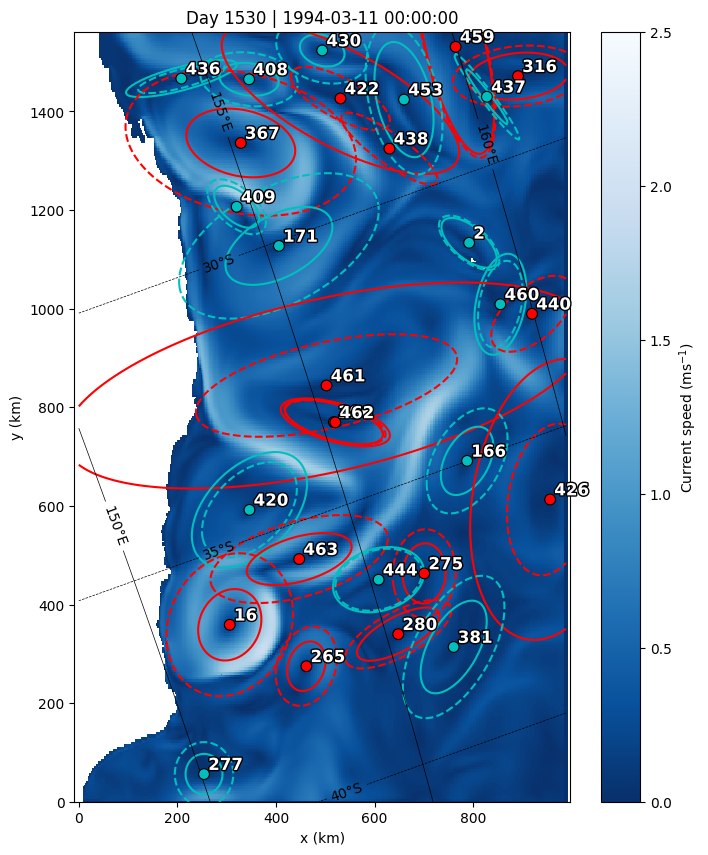

In [12]:
day_plot(1530, df_tracked)
